In [1]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt
from termcolor import colored 
import seaborn as sns
from PIL import Image
import keras
import matplotlib.image as mpimg

In [ ]:
#Main dataset folder and subfolder
#base_dir = kagglehub.dataset_download("antoreepjana/animals-detection-images-dataset")
base_dir = 'C:/***/PetImages'
os.listdir(base_dir)

['test', 'train']

In [4]:
sns.set_style('darkgrid')

In [5]:
#Train and test folders

train_dir = os.path.join(base_dir,'train')
test_dir = os.path.join(base_dir,'test')

In [6]:
#Number of classes

classes = os.listdir(train_dir)
num_classes = len(classes)
print(num_classes)

2


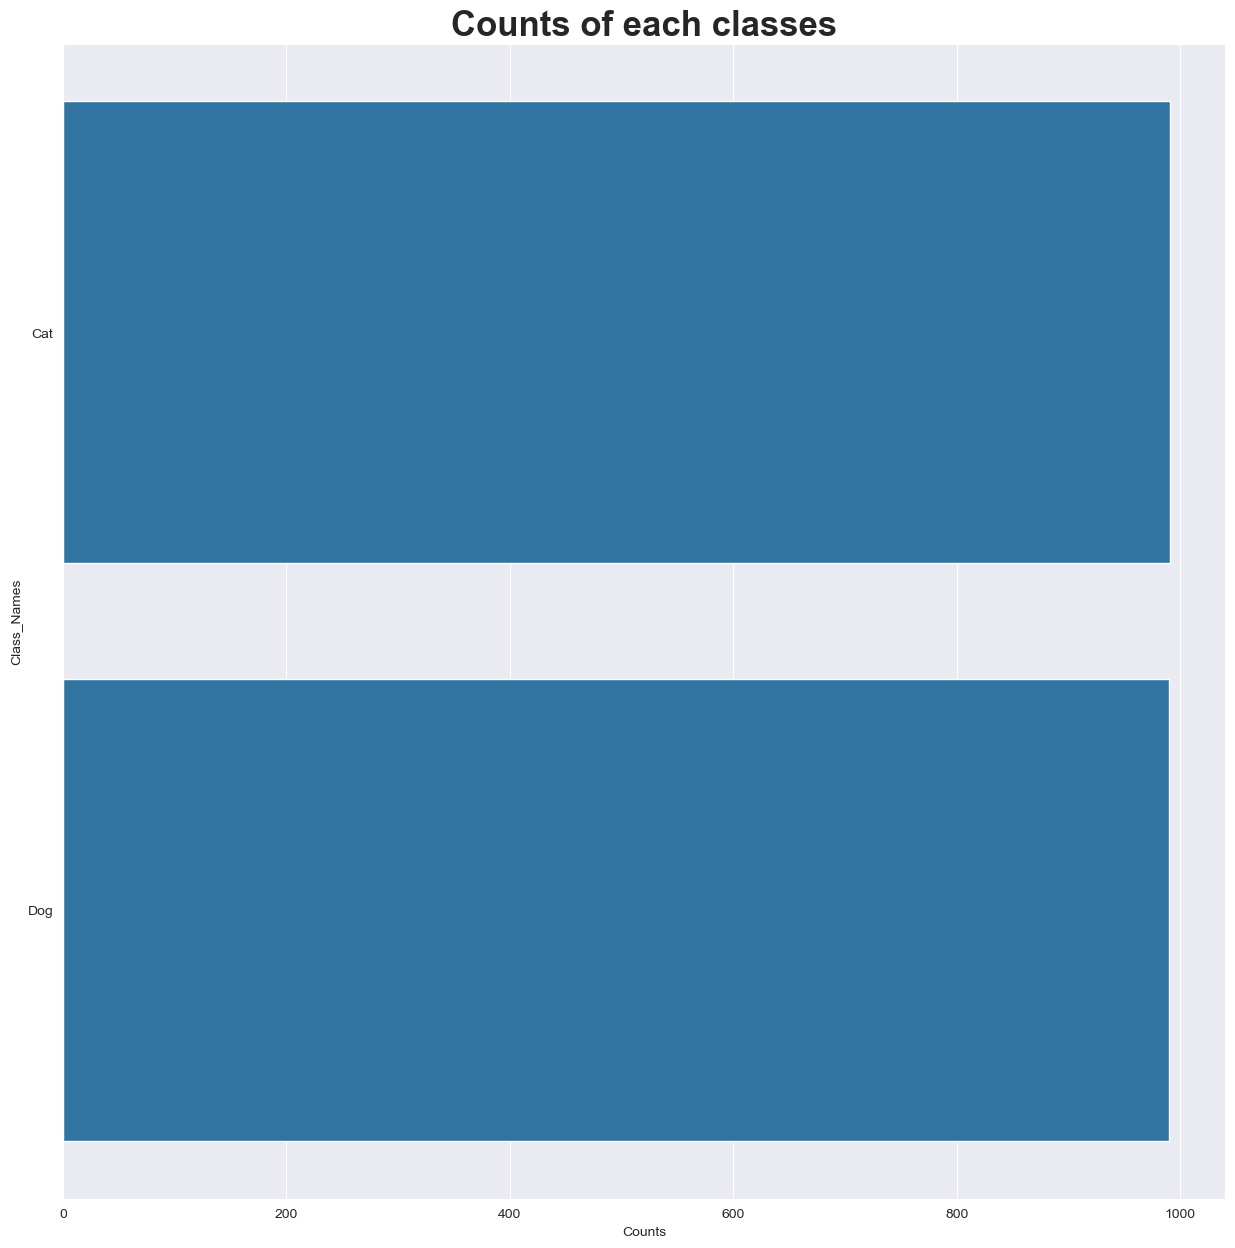

In [7]:
# Counting images per class

counts = []

for class_name in classes:
    class_path = os.path.join(train_dir,class_name)
    count = len(os.listdir(class_path))
    counts.append((class_name,count))

counts = pd.DataFrame(counts, columns=['Class_Names','Counts'])


plt.figure(figsize=(15, 15))
ax = sns.barplot(data=counts, y='Class_Names', x='Counts')
ax.set_title('Counts of each classes', fontsize=25, fontweight='bold')

plt.show()


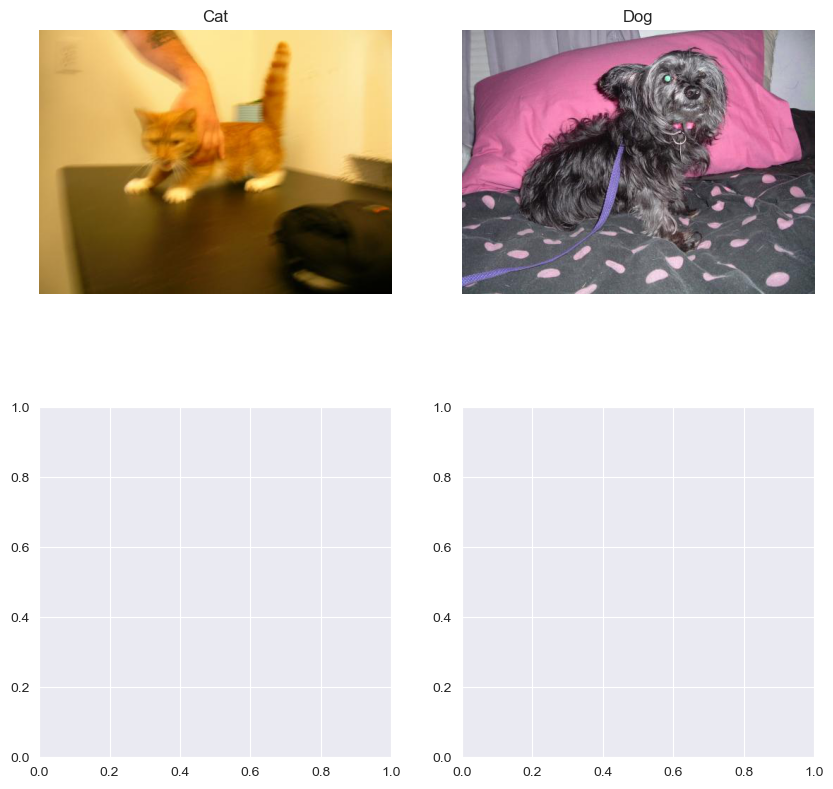

In [8]:
#Image show

#Define the plot size

fig, ax = plt.subplots(2,2,figsize=(10,10))

for i in range(len(classes)):
    class_name = classes[i]
    class_path = os.path.join(train_dir,class_name)
    img = [file for file in os.listdir(class_path) if file.endswith('.jpg')]
    img = os.path.join(class_path,img[0])
    img = Image.open(img)

    col = i // 10
    row = i % 10
    
    ax[col,row].imshow(img)
    ax[col,row].axis('off')
    ax[col,row].set_title(class_name)

plt.show()



In [9]:
#Data preprocessing

BATCH_SIZE = 32
IMAGE_SIZE = (224,224)

train_full = keras.utils.image_dataset_from_directory(
    directory = train_dir,
    labels = 'inferred',
    label_mode = 'categorical',
    class_names = classes,
    seed = 42,
    shuffle = True,
    batch_size = BATCH_SIZE,
    image_size=IMAGE_SIZE,
)


Found 1981 files belonging to 2 classes.


In [10]:
train_full = train_full.shuffle(1024).prefetch(tf.data.AUTOTUNE)

In [11]:
num_all_batches = len(list(train_full))
print(colored(f'Number of all Batches : {num_all_batches}', 'white', 'on_blue', attrs=['bold']))

Number of all Batches : 62


In [12]:
num_train_batches = int(num_all_batches*0.8)
number_valid_test_batches = int(num_all_batches - num_train_batches)
print('Number of Train batches', num_train_batches)
print('Number test batches', number_valid_test_batches//2)
print('Number validation batches', number_valid_test_batches//2)

Number of Train batches 49
Number test batches 6
Number validation batches 6


In [13]:
train_ds = train_full.take(num_train_batches)
remain = train_full.skip(num_train_batches)
valid_ds = remain.take(number_valid_test_batches//2)
test_ds = remain.skip(number_valid_test_batches//2)

print(colored(f'Number of train batches : {len(list(train_ds))}', 'green', attrs=['bold']))
print(colored(f'Number of valid batches : {len(list(valid_ds))}', 'green', attrs=['bold']))
print(colored(f'Number of test  batches : {len(list(test_ds))}', 'green', attrs=['bold']))

Number of train batches : 49
Number of valid batches : 6
Number of test  batches : 7


In [14]:
#Load VGG19 pretrained model with imagenet weights
pretrained_model = keras.applications.VGG19(
    weights='imagenet', classes=12, input_shape=(224, 224, 3), include_top=False
)

In [16]:
pretrained_model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
for layer in pretrained_model.layers:
    print(layer.name)

input_layer
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_conv4
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_conv4
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_conv4
block5_pool


In [18]:
#Train only the last layer of pretrained model

pretrained_model.trainable = True
set_trainable = False

for layer in pretrained_model.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False
        

In [19]:
model = keras.models.Sequential()
model.add(pretrained_model)                               # At first add our pre-trained model
model.add(keras.layers.Dropout(0.5))                      # Use a Dropout layer to avoid over-fitting
model.add(keras.layers.GlobalAveragePooling2D())          # Apply GlobalAveragePooling2D
model.add(keras.layers.Flatten())                         # Convert the output to 1D arraay
model.add(keras.layers.Dense(1024, activation='relu'))    # Add a Dense layer with 1024 neuron with activation='relu'
model.add(keras.layers.Dropout(0.5))                      # Use a Dropout layer to avoid over-fitting
model.add(keras.layers.Dense(512, activation='relu'))     # Add a Dense layer with 512 neuron with activation='relu'
model.add(keras.layers.Dropout(0.5))                      # Use a Dropout layer to avoid over-fitting
model.add(keras.layers.Dense(2, activation='softmax'))

In [20]:
#save best model parameters
checkpoint_cb = keras.callbacks.ModelCheckpoint('MyModel.keras', save_best_only=True) 

earlystop_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)


In [21]:
#Compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss = 'categorical_crossentropy', metrics=['accuracy'])

In [22]:
#Train the model
history = model.fit(train_ds,epochs = 100,validation_data=valid_ds,callbacks=[checkpoint_cb, earlystop_cb, reduce_lr])

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 737s 15s/step - accuracy: 0.7987 - loss: 0.5736 - val_accuracy: 0.9792 - val_loss: 0.0677 - learning_rate: 1.0000e-04
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 597s 12s/step - accuracy: 0.9369 - loss: 0.1546 - val_accuracy: 0.9479 - val_loss: 0.1160 - learning_rate: 1.0000e-04
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1140s 13s/step - accuracy: 0.9502 - loss: 0.1333 - val_accuracy: 1.0000 - val_loss: 0.0259 - learning_rate: 1.0000e-04
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 639s 13s/step - accuracy: 0.9770 - loss: 0.0610 - val_accuracy: 0.9896 - val_loss: 0.0301 - learning_rate: 1.0000e-04
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 627s 13s/step - accuracy: 0.9744 - loss: 0.0749 - val_accuracy: 0.9894 - val_loss: 0.0444 - learning_rate: 1.0000e-04
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 625s 13s/step - accuracy: 0.9783 - loss: 0.0634 - val_accuracy: 0.9792 - val_loss: 0.0619 - learning_rate: 1.0000e-04
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 626s 13s/step - ac

In [ ]:
# Convert result of training to a DataFrame
result_df = pd.DataFrame(history.history)
# Show 5 tails of dataframe
result_df.tail()

,accuracy,loss,val_accuracy,val_loss,learning_rate
55,1.0,0.000165,1.0,0.000680,1.000000e-06
56,1.0,0.000514,1.0,0.000041,1.000000e-06
57,1.0,0.000558,1.0,0.000100,1.000000e-06
58,1.0,0.000126,1.0,0.000004,1.000000e-06
59,1.0,0.000309,1.0,0.000015,1.000000e-06


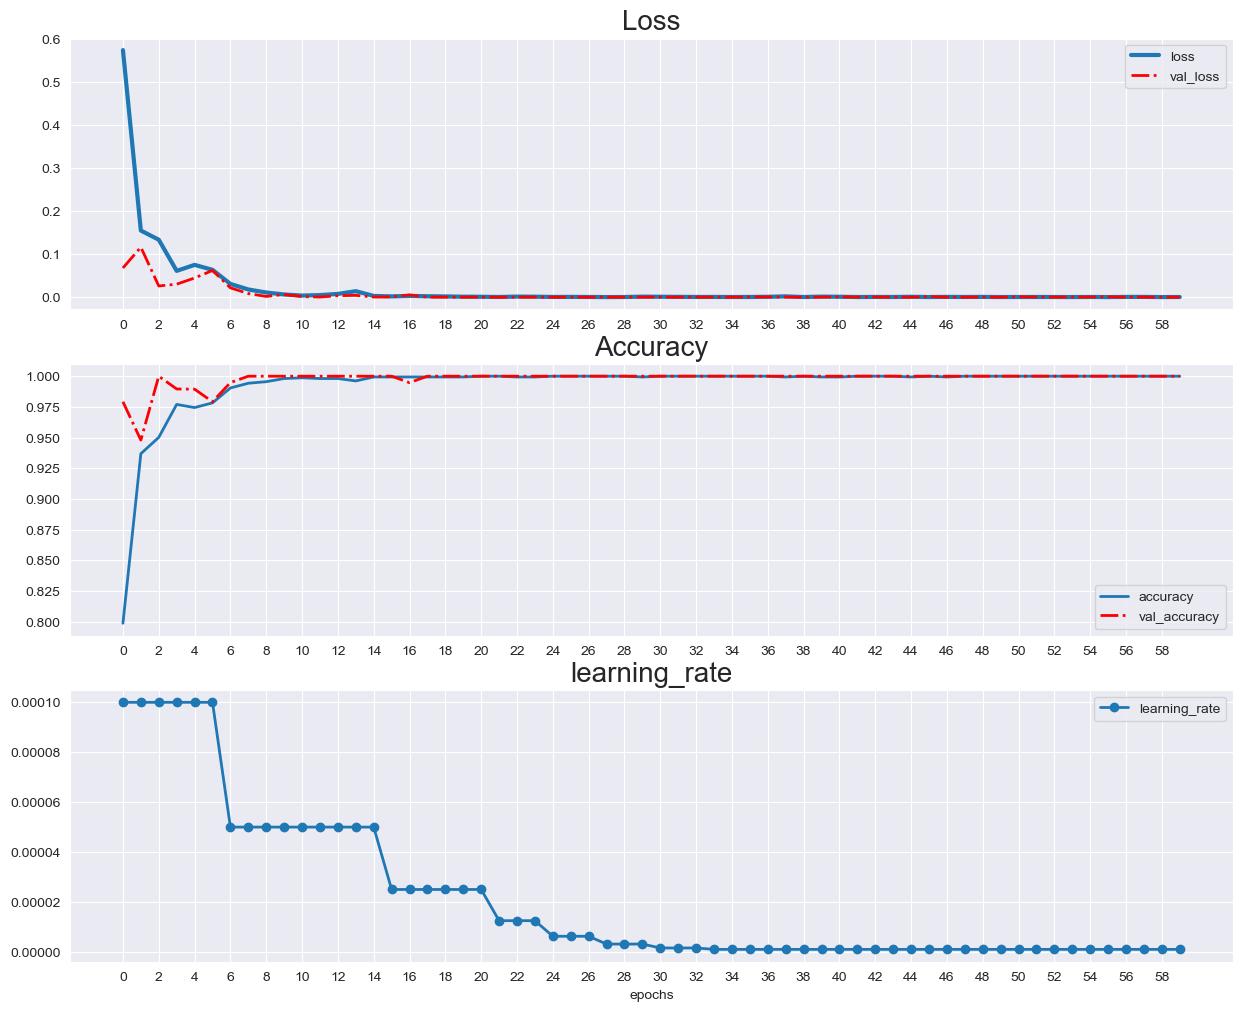

In [24]:
# Define a X variable to store range of epochs
x = np.arange(len(result_df))

# Create a plot with 3 row and 1 col with size of (15, 12)
fig, ax = plt.subplots(3, 1, figsize=(15, 12))

# AX0 : Loss
ax[0].plot(x, result_df.loss, label='loss', linewidth=3)                          
ax[0].plot(x, result_df.val_loss, label='val_loss', linewidth=2, ls='-.', c='r')
ax[0].set_title('Loss', fontsize=20)
ax[0].set_xticks(np.arange(0, len(x), 2))
ax[0].legend()

#  AX1 : Loss
ax[1].plot(x, result_df.accuracy, label='accuracy', linewidth=2)
ax[1].plot(x, result_df.val_accuracy, label='val_accuracy', linewidth=2, ls='-.', c='r')
ax[1].set_title('Accuracy', fontsize=20)
ax[1].set_xticks(np.arange(0, len(x), 2))
ax[1].legend()

#  AX2 : Loss
ax[2].plot(x, result_df.learning_rate, label='learning_rate', linewidth=2, marker='o')
ax[2].set_title('learning_rate', fontsize=20)
ax[2].set_xlabel('epochs')
ax[2].set_xticks(np.arange(0, len(x), 2))
ax[2].legend()

plt.show()

In [25]:
best_model = keras.models.load_model('MyModel.keras')


In [26]:
loss, accuracy = best_model.evaluate(test_ds)
print()
print(colored(f'Loss : {loss}', 'green', attrs=['bold']))
print(colored(f'Accuracy : {accuracy*100}%', 'green', attrs=['bold']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 88s 12s/step - accuracy: 1.0000 - loss: 7.7029e-05

Loss : 7.702912262175232e-05
Accuracy : 100.0%
